# Millennium-style rendering of StePS PDS snapshots

This notebook renders StePS simulation snapshots as **SPH-like adaptively smoothed,
logarithmic projected density maps** on a dark background — the classic
*Millennium simulation / Gadget* look of the images embedded in `StePS/README.md`
(info box with cosmic age and redshift, physical scale bar).

The rendering engine is [`millennium_render.py`](millennium_render.py) in this folder.
It is pure numpy/scipy/matplotlib (no `py-sphviewer` needed): each particle gets a
smoothing length from its $k$-th nearest neighbour distance in the projection, and the
mass deposition is done with a multi-scale histogram + Gaussian filter stack.

Default data source: the Poincaré Dodecahedral Space (S³/I\*) test run in
`data/pds_tests/test7b`. Point `SNAP_DIR` anywhere else to render other runs.

In [15]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from millennium_render import (load_snapshot, render_snapshot, render_map,
                               adaptive_density_map, age_of_universe_gyr,
                               make_evolution_gif)

# ── Configuration ──────────────────────────────────────────────────────────
SNAP_DIR = Path('/scratch/csabai/test256disc')   # relative to this notebook
OUT_DIR  = Path('/scratch/csabai/test256disc/renders')                          # rendered PNG/GIF output
NPIX     = 1200    # map resolution (pixels)
N_NGB    = 16      # neighbours for adaptive smoothing (smaller = sharper)
CMAP     = 'magma' # 'magma' and 'inferno' both give the Millennium look
DYN_RANGE = 2.5    # decades of surface density displayed
SLICE_THICKNESS = 10 

snap_files = sorted(SNAP_DIR.glob('snapshot_*.hdf5'))
OUT_DIR.mkdir(exist_ok=True)
print(f'Found {len(snap_files)} snapshots in {SNAP_DIR.resolve()}')

Found 11 snapshots in /scratch/csabai/test256disc


## Snapshot overview

In [16]:
import pandas as pd

rows = []
for s in snap_files:
    hdr = load_snapshot(s)['hdr']
    z   = float(hdr['Redshift'])
    h0  = float(hdr['HubbleParam']) * 100.0
    rows.append({'File': s.name,
                 'z': round(z, 4),
                 'Age [Gyr]': round(age_of_universe_gyr(z, h0, hdr['Omega0'], hdr['OmegaLambda']), 3),
                 'N': int(hdr['NumPart_ThisFile'][1]),
                 'R_sim [Mpc]': float(hdr.get('SimulationRadius', np.nan)),
                 'Topology': hdr.get('TopologicalManifold', '?')})
pd.DataFrame(rows).set_index('File')

,z,Age [Gyr],N,R_sim [Mpc],Topology
File,,,,,
snapshot_0000.hdf5,29.9962,0.100,6275736,960.0,S^3/I*
snapshot_0001.hdf5,14.9815,0.270,6275736,960.0,S^3/I*
snapshot_0002.hdf5,9.9981,0.474,6275736,960.0,S^3/I*
snapshot_0003.hdf5,4.9960,1.175,6275736,960.0,S^3/I*
snapshot_0004.hdf5,2.9968,2.150,6275736,960.0,S^3/I*
snapshot_0005.hdf5,1.9983,3.284,6275736,960.0,S^3/I*
snapshot_0006.hdf5,0.9985,5.862,6275736,960.0,S^3/I*
snapshot_0007.hdf5,0.6999,7.303,6275736,960.0,S^3/I*
snapshot_0008.hdf5,0.4990,8.602,6275736,960.0,S^3/I*


## Present-day universe (final snapshot)

Full projection of the simulation volume onto the X–Y plane.
With only ~12k particles in this test run, projecting the whole volume gives a
better picture than a thin slice; for large runs pass e.g.
`slice_thickness=20` (Mpc) to `render_snapshot`.

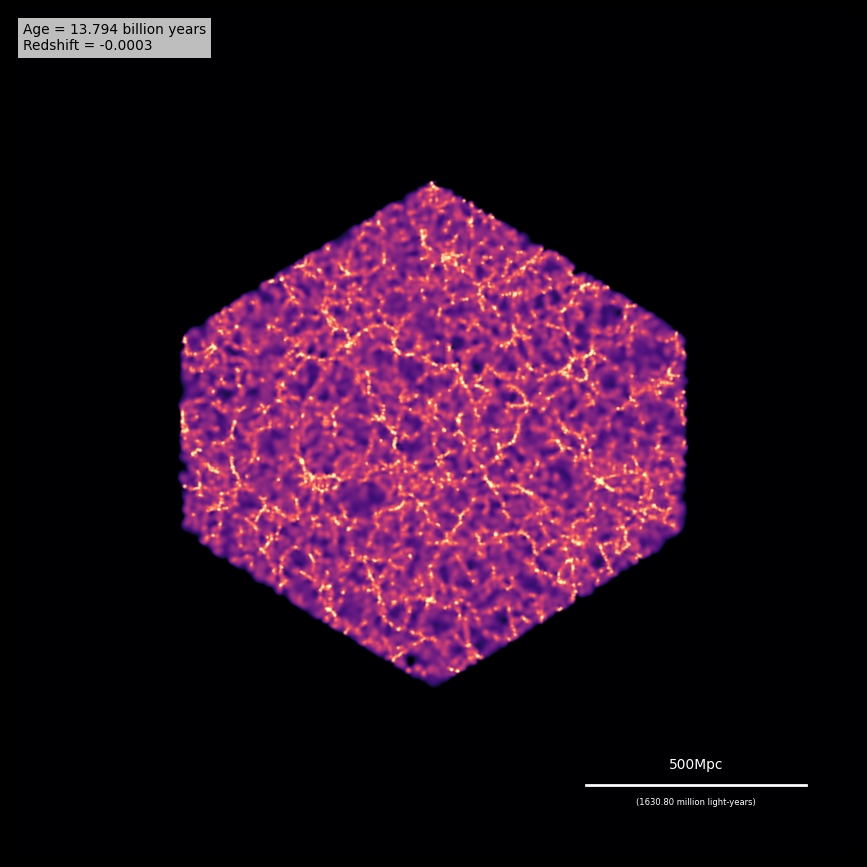

In [58]:
fig, ax = render_snapshot(snap_files[-1], plane='XY',
                          npix=NPIX, n_ngb=N_NGB, cmap=CMAP,
                          dyn_range=DYN_RANGE, figsize=11,slice_thickness=SLICE_THICKNESS)
fig.savefig(OUT_DIR / 'final_snapshot_XY.png', dpi=300,
            facecolor='black', bbox_inches='tight', pad_inches=0.02)
plt.show()

## Three projection planes

The dodecahedral fundamental domain is anisotropic, so the silhouette differs
between projection planes.

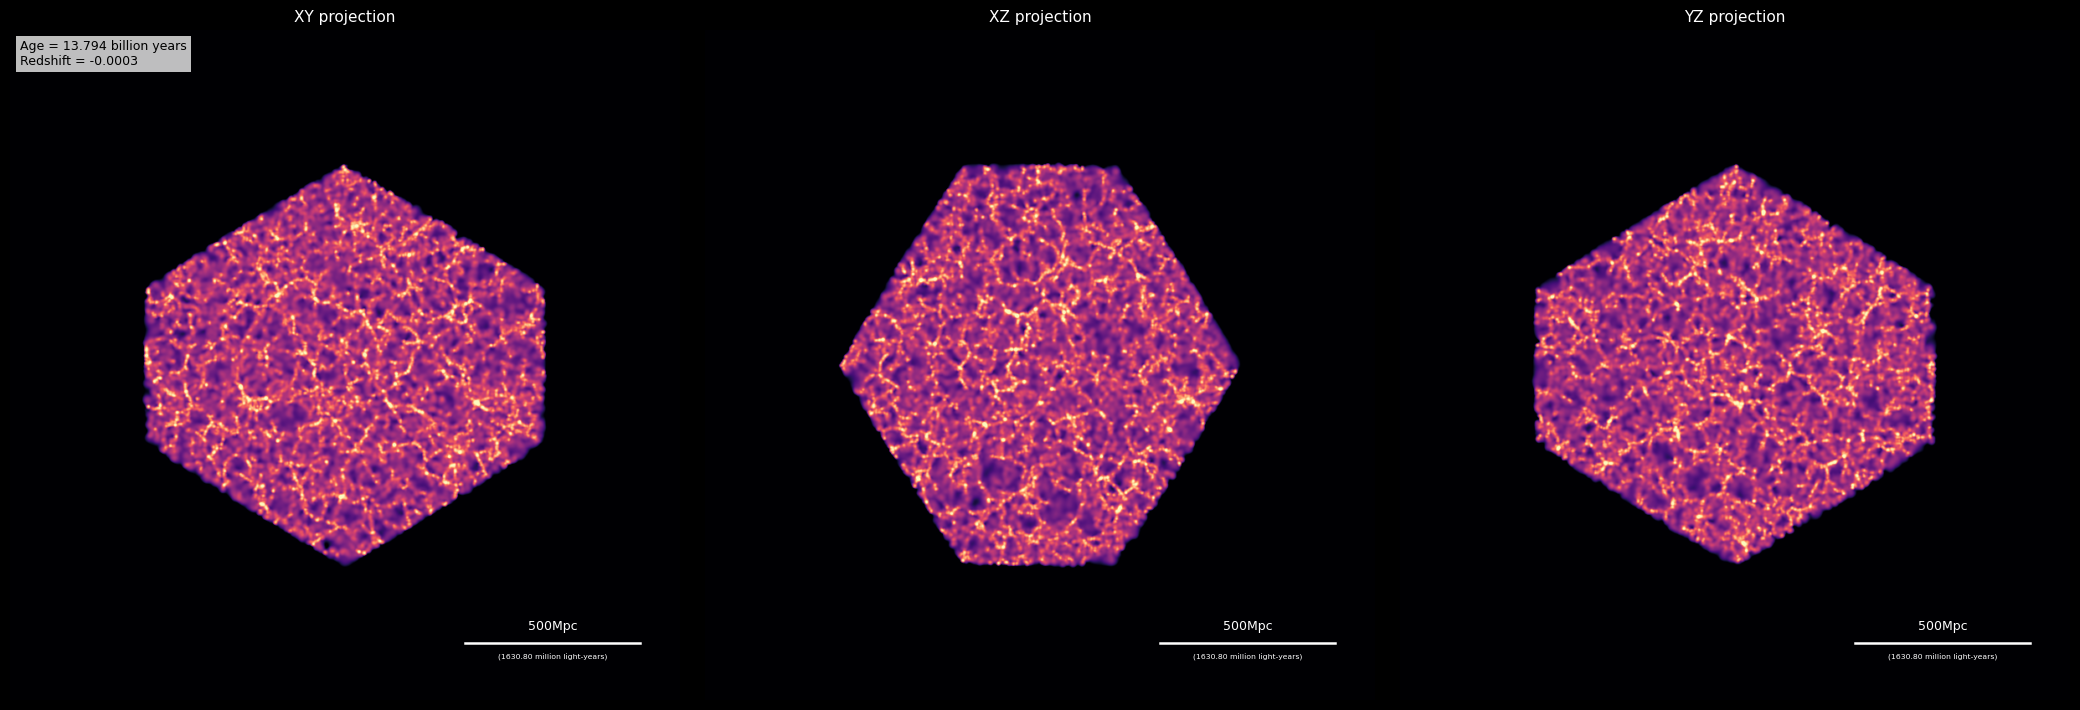

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.patch.set_facecolor('black')
for ax, plane in zip(axes, ['XY', 'XZ', 'YZ']):
    render_snapshot(snap_files[-1], plane=plane, npix=800, n_ngb=N_NGB, slice_thickness=SLICE_THICKNESS,
                    cmap=CMAP, dyn_range=DYN_RANGE, ax=ax,
                    info_box=(plane == 'XY'), title=f'{plane} projection')
plt.tight_layout()
plt.show()

## Evolution of the cosmic web

One panel per snapshot, from the initial grid at $z \approx 30$ to $z = 0$.
Each panel is normalized independently (the comoving density contrast grows
by orders of magnitude during the run).

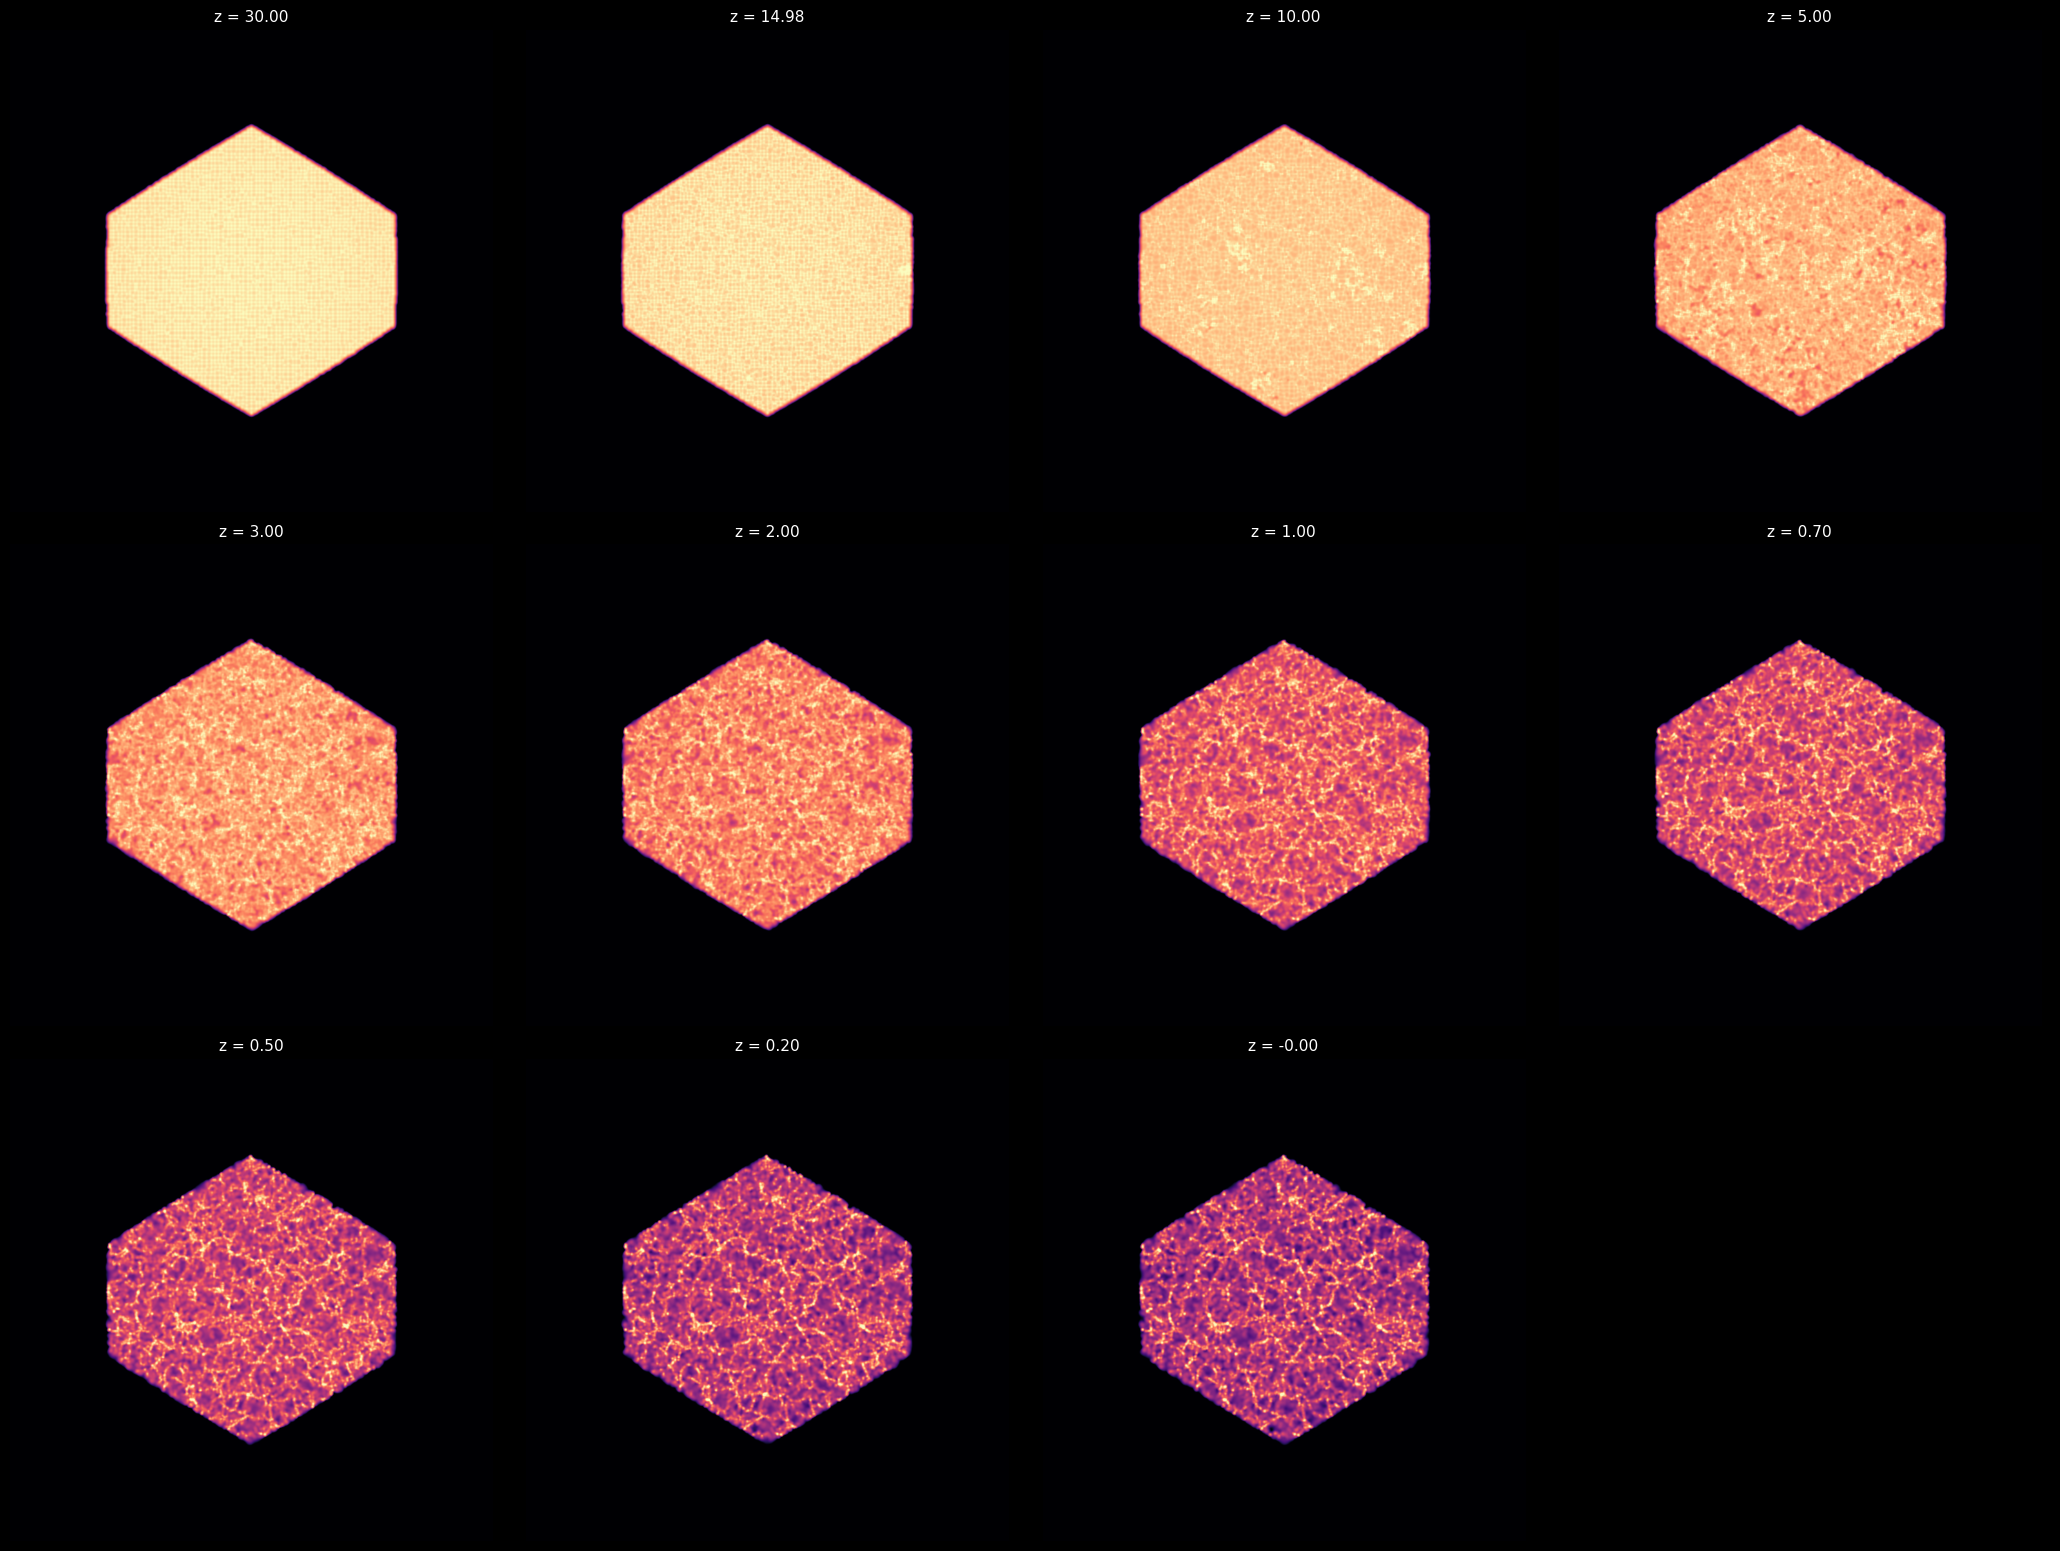

In [19]:
ncol = 4
nrow = int(np.ceil(len(snap_files) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.2*ncol, 5.2*nrow))
fig.patch.set_facecolor('black')
for ax in axes.flat:
    ax.set_axis_off()
    ax.set_facecolor('black')
for ax, s in zip(axes.flat, snap_files):
    hdr = load_snapshot(s)['hdr']
    ax.set_axis_on()
    render_snapshot(s, plane='XY', npix=700, n_ngb=N_NGB, cmap=CMAP, slice_thickness=SLICE_THICKNESS,
                    dyn_range=DYN_RANGE, ax=ax, info_box=False, scale_bar=False,
                    title=f"z = {float(hdr['Redshift']):.2f}")
plt.tight_layout()
fig.savefig(OUT_DIR / 'evolution_mosaic.png', dpi=110,
            facecolor='black', bbox_inches='tight', pad_inches=0.05)
plt.show()

## Animated GIF

Renders every snapshot to a frame and assembles `renders/evolution.gif`
(also writes the individual frames as PNGs).

In [20]:
for s in snap_files:
    hdr = load_snapshot(s)['hdr']
    fig, _ = render_snapshot(s, plane='XY', npix=NPIX, n_ngb=N_NGB,slice_thickness=SLICE_THICKNESS,
                             cmap=CMAP, dyn_range=DYN_RANGE, figsize=9)
    fig.savefig(OUT_DIR / (s.stem + '.png'), dpi=120,
                facecolor='black', bbox_inches='tight', pad_inches=0.02)
    plt.close(fig)
    print(f"rendered {s.name}  (z = {float(hdr['Redshift']):6.2f})")

make_evolution_gif(snap_files, OUT_DIR / 'evolution.gif', fps=2,
                   plane='XY', npix=NPIX, n_ngb=N_NGB,
                   cmap=CMAP, dyn_range=DYN_RANGE, figsize=9)

rendered snapshot_0000.hdf5  (z =  30.00)
rendered snapshot_0001.hdf5  (z =  14.98)
rendered snapshot_0002.hdf5  (z =  10.00)
rendered snapshot_0003.hdf5  (z =   5.00)
rendered snapshot_0004.hdf5  (z =   3.00)
rendered snapshot_0005.hdf5  (z =   2.00)
rendered snapshot_0006.hdf5  (z =   1.00)
rendered snapshot_0007.hdf5  (z =   0.70)
rendered snapshot_0008.hdf5  (z =   0.50)
rendered snapshot_0009.hdf5  (z =   0.20)
rendered snapshot_0010.hdf5  (z =  -0.00)
Wrote /scratch/csabai/test256disc/renders/evolution.gif (11 frames)


## Parameter guide

| Parameter | Effect |
|---|---|
| `npix` | map resolution; 1000–2000 for stills, ~700 for mosaics |
| `n_ngb` | adaptive smoothing neighbours — smaller is sharper but noisier (try 8–48) |
| `dyn_range` | decades of surface density shown; larger reveals fainter structure |
| `vmax_percentile` | clip of the bright end; lower it (e.g. 99.5) if a few knots saturate |
| `cmap` | `magma`, `inferno`, `hot`, or a custom Gadget palette |
| `slice_thickness` | thin-slice mode in Mpc (like `plot_hdf5_snapshot_slice.py`); `None` = full projection |
| `r_plot` | half-size of the rendered region in Mpc (zoom with smaller values) |

`render_snapshot` accepts any StePS HDF5 snapshot — the renderer only uses
`PartType1/Coordinates`, `Masses`, and the header, so it works for spherical
and cylindrical StePS runs as well as the PDS (S³/I\*) topology.

In [21]:
t = load_snapshot(Path('/scratch/csabai/test256disc/snapshot_0010.hdf5'))
t_center_slice = t['pos']#[np.abs(t['pos'][:, 2]) < 80]
# 80 mpc radius slice in the XY plane, centered at Z=0
t_center_slice = t_center_slice[np.linalg.norm(t_center_slice[:, :], axis=1) < 87.8]
# load T3 snapshot from /scratch/csabai/testCubic128/snapshot_0010.hdf5
#t2 = load_snapshot(Path('/scratch/csabai/testCubic128/snapshot_0010.hdf5'))
#t2 = load_snapshot(Path('/scratch/csabai/test128/snapshot_0010.hdf5'))
#t2 = load_snapshot(Path('/scratch/csabai/testSphere/snapshot_0002.hdf5'))
#t2_center_slice = t2['pos']
#t2_center_slice = t2_center_slice[np.linalg.norm(t2_center_slice[:, :], axis=1) < 87.8]
#2_center_slice = t2['pos'][np.abs(t2['pos'][:, 0]) < 80]
#t2_center_slice = t2_center_slice[np.linalg.norm(t2_center_slice[:, 1:], axis=1) < 80]

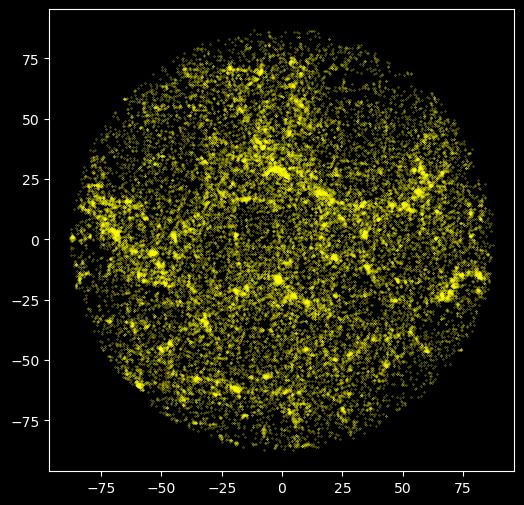

In [22]:
plt.style.use('dark_background')
plt.figure(figsize=(6, 6))
plt.scatter(t_center_slice[:, 0], t_center_slice[:, 1], s=0.05, c='yellow')

### Opposite face slices

(420.0, 495.0)

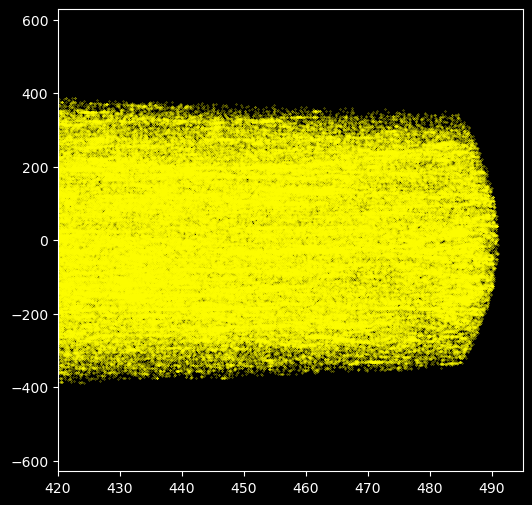

In [ ]:
# rotate t around z axis by 36 degrees and plot it
# phi=(1+sqrt(5))/2, theta = 1/atan(phi) = 31.7174744115 degrees
t = load_snapshot(Path('/scratch/csabai/test256disc/snapshot_0010.hdf5'))['pos']
rotated_t = t.copy()
theta = np.radians(31.7174744115)
rotation_matrix = np.array([[np.cos(theta), 0, -np.sin(theta)],
                            [0, 1, 0],
                            [np.sin(theta), 0, np.cos(theta)],
                            ])
rotated_t = rotated_t @ rotation_matrix.T
plt.style.use('dark_background')
plt.figure(figsize=(6, 6))
plt.scatter(rotated_t[:, 0], rotated_t[:, 1], s=0.05, c='yellow', alpha=1)
plt.xlim(420,495)
#print(np.max(rotated_t[:, 0]))


### Opposite faces should have correlated density patterns 

After rotating one of them by 36 degrees. Looks good.

The PDS fundamental domain is a spherical dodecahedron — the curved-space cell of S³/I*, not a flat-faced Euclidean dodecahedron. Its faces are totally geodesic 2-spheres on S³ (the curved-space analog of flat faces: they're the perpendicular bisectors between adjacent cell centers). The snapshot Coordinates are the stereographic projection of S³ into R³, and stereographic projection maps those geodesic faces to spheres in the chart — so a face seen edge-on projects to an arc, not a straight line.

You'd only get straight edges if (a) the space were Euclidean, or (b) you used a projection that maps geodesics to straight lines. That projection is the gnomonic (central) one: x_gnom = R·q_vec/q₀ instead of stereographic x_stereo = R·q_vec/(1+q₀). 

Text(0, 0.5, 'Z [Mpc]')

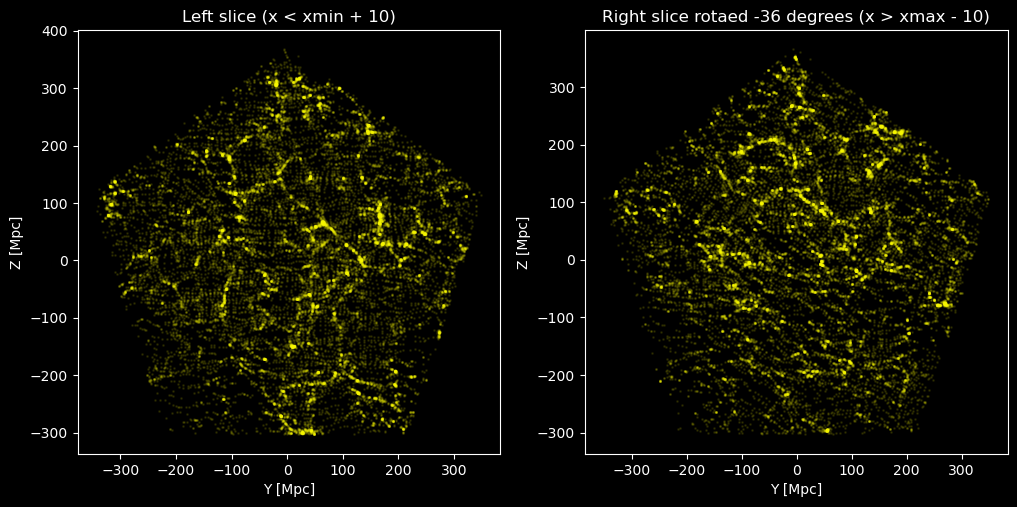

In [100]:
cutIdx = 0
idx1 = 1
idx2 = 2
slice_thickness = 10
xmin = np.min(rotated_t[:, cutIdx])
xmax = np.max(rotated_t[:, cutIdx])
t_left_slice = rotated_t[rotated_t[:, cutIdx] < xmin + slice_thickness]
t_left_slice2 = rotated_t[(rotated_t[:, cutIdx] < xmin + 2*slice_thickness) & 
                          (rotated_t[:, cutIdx] >= xmin + slice_thickness)]
t_right_slice = rotated_t[rotated_t[:, cutIdx] > xmax - slice_thickness]
# rotate around x axis 36 degress
theta = np.radians(-36)
rotation_matrix2 = np.array([[1, 0, 0],
                            [0,np.cos(theta), -np.sin(theta)],                            
                            [0,np.sin(theta), np.cos(theta)],
                            ])
t_right_slice = t_right_slice @ rotation_matrix2.T
# two panel plot of the left and right slices
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].scatter(t_left_slice[:, idx1], t_left_slice[:, idx2], s=1, c='yellow', alpha=0.1)
axes[0].set_title('Left slice (x < xmin + ' +str(slice_thickness) + ')')
axes[0].set_xlabel('Y [Mpc]')
axes[0].set_ylabel('Z [Mpc]')
#axes[1].scatter(t_left_slice2[:, idx1], t_left_slice2[:, idx2], s=0.1, c='yellow')
axes[1].scatter(t_right_slice[:, idx1], t_right_slice[:, idx2], s=1, c='yellow', alpha=0.1)
axes[1].set_title('Right slice rotaed -36 degrees (x > xmax - ' +str(slice_thickness) + ')')
axes[1].set_xlabel('Y [Mpc]')
axes[1].set_ylabel('Z [Mpc]')
